# Agentic Data Analyst - LangGraph Implementation

This notebook contains the full implementation of the self-correcting agentic data analyst using LangGraph. The system includes SQL drafting, automated execution, routing logic, and visualization generation with a self-correction loop.

## 1. Imports and Configuration

First, we import the necessary libraries and configure the NVIDIA NIM chat model.

In [13]:
import os
import sqlite3
import re
import pandas as pd
import plotly.express as px
from typing import List, Any
from pydantic import BaseModel, Field
from dotenv import load_dotenv

# LangGraph imports
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_nvidia_ai_endpoints import ChatNVIDIA

# Load environment variables (ensure NVIDIA_API_KEY is set in your .env file)
load_dotenv()

def get_chat_model():
    """
    Initializes and returns the ChatNVIDIA model configured for reasoning.
    """
    return ChatNVIDIA(
        model="nvidia/nemotron-3-super-120b-a12b",
        temperature=0,
        max_tokens=16384,
        reasoning_budget=16384,
        chat_template_kwargs={"enable_thinking": True},
    )

llm = get_chat_model()

C:\Users\user\AppData\Local\Temp\ipykernel_30800\2532683201.py:23: DeprecationWarning: The 'max_tokens' parameter is deprecated and will be removed in a future version. Please use 'max_completion_tokens' instead.
  return ChatNVIDIA(
C:\Users\user\AppData\Local\Temp\ipykernel_30800\2532683201.py:31: UserWarning: WARNING! reasoning_budget is not default parameter.
                reasoning_budget was transferred to model_kwargs.
                Please confirm that reasoning_budget is what you intended.
  llm = get_chat_model()
C:\Users\user\AppData\Local\Temp\ipykernel_30800\2532683201.py:31: UserWarning: WARNING! chat_template_kwargs is not default parameter.
                chat_template_kwargs was transferred to model_kwargs.
                Please confirm that chat_template_kwargs is what you intended.
  llm = get_chat_model()


## 2. Prompt Library

Below are the specialized system prompts used by the various agents in the analysis graph.

### Router Prompt
Used to decide if the user's question requires a visualization.

In [14]:
ROUTER_PROMPT = """
<OBJECTIVE_AND_PERSONA>
You are an Intelligent Routing Agent. Your task is to analyze a user's question and determine if the response would benefit from a visual chart (e.g., bar chart, line graph, pie chart) or if a simple text/table summary is sufficient.
</OBJECTIVE_AND_PERSONA>

<INPUT>
1. User Question: The original query provided by the user.
</INPUT>

<INSTRUCTIONS>
To complete the task, you need to follow these steps:
1. Evaluate the Question: Check if the user is asking for trends, comparisons, distributions, or rankings (e.g., "over time", "compared to", "top 10", "distribution of").
2. Determine Visualization Need: 
   - If the answer is naturally visual (trends, proportions, complex comparisons), decide YES.
   - If the answer is a single data point, a simple list, or a direct factual lookup, decide NO.
3. Output the Decision: Provide ONLY the word 'YES' or 'NO'.
</INSTRUCTIONS>

<CONSTRAINTS>
1. Dos:
   - Output ONLY 'YES' or 'NO'.
   - Bias towards 'YES' if the user uses words like "visualize", "chart", "graph", or "plot".
2. Don'ts:
   - DO NOT provide any reasoning or explanation.
   - DO NOT include punctuation or markdown.
</CONSTRAINTS>

<OUTPUT_FORMAT>
A single string: either 'YES' or 'NO'.
</OUTPUT_FORMAT>

<RECAP>
Analyze the question for visual potential. Output ONLY 'YES' if a chart is needed, otherwise ONLY 'NO'.
</RECAP>
"""

### SQL Drafter Prompt
Used to translate natural language into SQLite queries.

In [15]:
SQL_DRAFTER_PROMPT = """
<OBJECTIVE_AND_PERSONA>
You are an Expert SQLite Database Engineer. Your task is to translate natural language business questions into syntactically perfect SQLite queries. You are precise, cautious about schema details, and focused on returning high-quality, executable code that answers the user's specific information needs.
</OBJECTIVE_AND_PERSONA>

<INPUT>
1. User Question: The original business query provided by the user.
2. Database Schema: The structural blueprint of the SQLite database (table names, column names, and data types).
3. Previous SQL Error (Optional): If this is a retry attempt, you will receive the error message from the last failed execution to help you fix the logic.
</INPUT>

<INSTRUCTIONS>
To complete the task, you need to follow these steps:
1. Analyze the Schema: Carefully review the provided table and column names. Ensure you only use columns that actually exist.
2. Interpret the Question: Identify the core metrics, filters, and aggregations requested by the user.
3. Handle Errors (if applicable): If a 'Previous SQL Error' is provided, diagnose why the previous query failed (e.g., syntax error, missing column, or incorrect data type) and correct it.
4. Construct the Query: Write a standard SQLite-compatible query.
5. Format the Output: Provide ONLY the raw SQL code.
</INSTRUCTIONS>

<CONSTRAINTS>
1. Dos:
   - Use standard SQLite syntax.
   - Use aliases for readability if joining tables.
   - Use LIMIT if the user asks for "top" or "bottom" results.
   - Use column names EXACTLY as they appear in the schema.
2. Don'ts:
   - DO NOT include markdown code blocks (e.g., ```sql).
   - DO NOT include any conversational text, explanations, or "Here is your query".
   - DO NOT invent columns or tables that are not in the provided schema.
   - DO NOT use PostgreSQL or MySQL-specific functions (e.g., no 'ILIKE', use 'LIKE').
</CONSTRAINTS>

<CONTEXT>
The database contains multiple tables uploaded by the user. Carefully inspect the schema to identify which tables and columns are needed. If the user's question requires information from multiple files, perform the appropriate JOINs using shared keys (e.g., matching IDs or Names).
</CONTEXT>

<OUTPUT_FORMAT>
The output must be a single string containing only the valid SQLite query.
Example: SELECT column_name FROM table_name WHERE condition;
</OUTPUT_FORMAT>

<RECAP>
Remember: Output ONLY the raw SQL. No markdown, no explanations. Ensure the query is compatible with SQLite and uses only the columns provided in the schema. If an error was provided, address it directly in your new draft.
</RECAP>
"""

### Visualization Drafter Prompt
Used to generate Python code for Plotly charts.

In [16]:
VISUALIZATION_PROMPT = """
<OBJECTIVE_AND_PERSONA>
You are a Data Visualization Expert specializing in Plotly. Your task is to write Python code that generates a clear, interactive, and aesthetically pleasing chart based on the provided data and the user's question. 
</OBJECTIVE_AND_PERSONA>

<INPUT>
1. User Question: The original query to understand the context of the visualization.
2. Retrieved Data: A list of tuples or dictionaries containing the raw database results.
3. Previous Python Error (Optional): If provided, fix the code to resolve this specific error.
</INPUT>

<INSTRUCTIONS>
To complete the task, you need to follow these steps:
1. Identify Chart Type: Choose the best Plotly chart (e.g., px.bar, px.line, px.pie, px.scatter) for the data.
2. Prepare Data: The variable 'data' is already available in the execution environment as a list of dictionaries. Convert it into a Pandas DataFrame if necessary.
3. Create Figure: Use Plotly Express (px) to create a figure named 'fig'.
4. Customize Appearance: Add a relevant title and ensure labels are human-readable. Use a modern template like 'plotly_white'.
5. Output Code: Provide ONLY the Python code. Do not include any imports (they are pre-loaded) or 'fig.show()'.
</INSTRUCTIONS>

<CONSTRAINTS>
1. Dos:
   - Assume 'import plotly.express as px' and 'import pandas as pd' are already executed.
   - Name your final figure object 'fig'.
   - Ensure the code is self-contained and runs on the variable named 'data'.
2. Don'ts:
   - DO NOT include code blocks (```python).
   - DO NOT include explanations or comments.
   - DO NOT include 'fig.show()' or 'st.plotly_chart()'.
   - DO NOT import any libraries.
</CONSTRAINTS>

<CONTEXT>
The code will be executed in a restricted environment where 'data', 'pd', and 'px' are already defined. The 'data' variable contains the results from the SQL executor.
</CONTEXT>

<OUTPUT_FORMAT>
The output must be pure Python code that defines a Plotly figure object 'fig'.
Example:
df = pd.DataFrame(data)
fig = px.bar(df, x='column_a', y='column_b', title='Chart Title')
</OUTPUT_FORMAT>

<RECAP>
Write ONLY the Python code to create a Plotly figure 'fig' from the variable 'data'. No markdown, no imports, no fig.show().
</RECAP>
"""

### Lead Analyst Summary Prompt
Used to synthesize the final analytical response.

In [17]:
SUMMARY_PROMPT = """
<OBJECTIVE_AND_PERSONA>
You are the Lead Data Analyst. Your task is to synthesize raw data results into a clear, concise, and professional executive summary that directly answers the user's original business question. You provide context, highlight key findings, and maintain a helpful, analytical tone.
</OBJECTIVE_AND_PERSONA>

<INPUT>
1. User Question: The original business query.
2. Retrieved Data: The raw rows/data points extracted from the database.
3. Visualization Status: Whether a chart was generated to accompany this text.
</INPUT>

<INSTRUCTIONS>
To complete the task, you need to follow these steps:
1. Analyze the Data: Review the retrieved rows and identify the most important numbers or trends.
2. Direct Answer: Start by directly answering the user's question in the first sentence.
3. Provide Context: Explain what the data means in a business context. Mention specific values from the 'Retrieved Data'.
4. Reference Visualization: If the Visualization Status indicates a chart was created, briefly mention it (e.g., "As shown in the accompanying chart...").
5. Format the Output: Use professional markdown. Keep it concise but thorough.
</INSTRUCTIONS>

<CONSTRAINTS>
1. Dos:
   - Use professional and analytical language.
   - Use bold text for key metrics.
   - Be honest about the data; if no data was found, state that clearly.
2. Don'ts:
   - DO NOT hallucinate data points not present in the 'Retrieved Data'.
   - DO NOT use overly technical jargon (e.g., "the SQL query returned...").
   - DO NOT be repetitive.
</CONSTRAINTS>

<OUTPUT_FORMAT>
The output must be formatted in Markdown.
- Use a header or bold first line for the main answer.
- Use bullet points if listing multiple insights.
</OUTPUT_FORMAT>

<RECAP>
You are the final voice of the analysis. Ensure the user understands the 'what' and the 'so what' of the data provided. Answer clearly, use the raw data accurately, and maintain an executive tone.
</RECAP>
"""

### Column Description Prompt
Used for automated data profiling and column documentation.

In [18]:
COLUMN_DESCRIPTION_PROMPT = """
<OBJECTIVE_AND_PERSONA>
You are a Data Profiling Expert. Your task is to analyze the schema and sample data of a database table and provide a brief, professional description for each column.
</OBJECTIVE_AND_PERSONA>

<INPUT_CONTEXT>
You will receive:
1. Total row and column counts.
2. Column-level statistics (data type, unique counts, sample values).
3. A preview of the first few rows.
</INPUT_CONTEXT>

<INSTRUCTIONS>
1. **Analyze**: Use column names, data types, and sample values to infer the business meaning (e.g., 'ID' is a unique identifier, 'Revenue' is monetary gain).
2. **Describe**: Write a concise, one-sentence professional description for each column.
3. **Format**: Return ONLY a valid JSON object. The keys must exactly match the column names provided in the input.
</INSTRUCTIONS>

<CONSTRAINTS>
- Return ONLY the JSON object. No preamble, no postscript, no markdown code blocks.
- Ensure all keys match the column names exactly.
- If a column's purpose is unclear, provide a high-level description based on its data type and values.
</CONSTRAINTS>

<OUTPUT_FORMAT_EXAMPLE>
{
  "customer_id": "A unique identifier assigned to each individual customer.",
  "transaction_date": "The timestamp indicating when the financial transaction occurred."
}
</OUTPUT_FORMAT_EXAMPLE>
"""

## 3. State and Utilities

This section defines the `AgentState` and reasoning extraction utility.

In [19]:
class AgentState(BaseModel):
    user_question: str = Field(description="What the user asked initially")
    file_name: str = Field(description="Context and name of the uploaded file")
    session_id: str = Field(default="default", description="Unique ID for user session")
    db_path: str = Field(default="sessions/temp.db", description="Path to the session SQLite database")
    schema_info: str = Field(default="", description="The dynamically extracted database schema")
    sql_query: str = Field(default="", description="The generated SQL code drafted by the LLM")
    sql_error: str = Field(default="", description="Captures execution errors for the correction loop")
    raw_data: List[Any] = Field(default_factory=list, description="The successfully retrieved database rows")
    needs_chart: bool = Field(default=False, description="Router decision flag")
    plotly_code: str = Field(default="", description="The generated Python visualization code")
    visualization_error: str = Field(default="", description="Captures Python execution errors")
    final_summary: str = Field(default="", description="The final analytical output")
    sql_retry_count: int = Field(default=0, description="Current number of retries in SQL loop")
    viz_retry_count: int = Field(default=0, description="Current number of retries in Viz loop")
    reasoning_log: List[dict] = Field(default_factory=list, description="Internal reasoning log")

def extract_reasoning(response, agent_name, state):
    """Extracts reasoning from NIM metadata or additional_kwargs."""
    reasoning = ""
    if hasattr(response, "response_metadata"):
        ctk = response.response_metadata.get("chat_template_kwargs", {})
        if isinstance(ctk, dict): reasoning = ctk.get("thinking", "")
        elif isinstance(ctk, str): reasoning = ctk
    if not reasoning and hasattr(response, "additional_kwargs"):
        reasoning = response.additional_kwargs.get("reasoning_content", "")
    
    new_log = state.reasoning_log.copy()
    if reasoning: new_log.append({"agent": agent_name, "content": reasoning})
    return new_log

## 4. Node Implementations (Agents)

We implement the core logic for each step in the analysis pipeline as LangGraph nodes.

In [20]:
def schema_extractor(state: AgentState):
    """Extracts schema and sample values from the SQLite database."""
    schema_parts = []
    try:
        with sqlite3.connect(state.db_path) as conn:
            cursor = conn.cursor()
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
            for table in cursor.fetchall():
                table_name = table[0]
                schema_parts.append(f"Table: {table_name}")
                cursor.execute(f"PRAGMA table_info({table_name});")
                for col in cursor.fetchall():
                    col_name, col_type = col[1], col[2]
                    cursor.execute(f"SELECT DISTINCT `{col_name}` FROM `{table_name}` WHERE `{col_name}` IS NOT NULL LIMIT 3;")
                    samples = [str(r[0]) for r in cursor.fetchall()]
                    schema_parts.append(f"  - {col_name} ({col_type}) Samples: {samples}")
    except Exception as e: return {"schema_info": str(e)}
    return {"schema_info": "\n".join(schema_parts)}

def sql_drafter(state: AgentState):
    """Drafts a SQL query based on the question and schema."""
    msg = f"Q: {state.user_question}\nSchema: {state.schema_info}"
    if state.sql_error: msg += f"\nError: {state.sql_error}"
    res = llm.invoke([{"role": "system", "content": SQL_DRAFTER_PROMPT}, {"role": "user", "content": msg}])
    query = re.sub(r"```(?:sql)?|```", "", res.content).strip()
    return {"sql_query": query, "sql_retry_count": state.sql_retry_count + (1 if state.sql_error else 0), "reasoning_log": extract_reasoning(res, "SQL Drafter", state)}

def router(state: AgentState):
    """Determines if a chart is needed."""
    res = llm.invoke([{"role": "system", "content": ROUTER_PROMPT}, {"role": "user", "content": state.user_question}])
    return {"needs_chart": "YES" in res.content.upper(), "reasoning_log": extract_reasoning(res, "Router", state)}

def visualization_drafter(state: AgentState):
    """Generates Plotly code for visualization."""
    df = pd.DataFrame(state.raw_data)
    msg = f"Q: {state.user_question}\nStats: {df.describe().to_string()}"
    if state.visualization_error: msg += f"\nError: {state.visualization_error}"
    res = llm.invoke([{"role": "system", "content": VISUALIZATION_PROMPT}, {"role": "user", "content": msg}])
    code = re.sub(r"```(?:python)?|```", "", res.content).strip()
    return {"plotly_code": code, "viz_retry_count": state.viz_retry_count + (1 if state.visualization_error else 0), "reasoning_log": extract_reasoning(res, "Viz Drafter", state)}

def inference_agent(state: AgentState):
    """Generates the final summary."""
    df = pd.DataFrame(state.raw_data)
    msg = f"Q: {state.user_question}\nSummary: {df.describe().to_string()}"
    res = llm.invoke([{"role": "system", "content": SUMMARY_PROMPT}, {"role": "user", "content": msg}])
    return {"final_summary": res.content, "reasoning_log": extract_reasoning(res, "Lead Analyst", state)}

## 5. Node Implementations (Tools)

These nodes perform the actual execution of SQL and Python code.

In [21]:
def sql_executor(state: AgentState):
    """Executes the SQL query in read-only mode."""
    try:
        db_uri = f"file:{os.path.abspath(state.db_path)}?mode=ro"
        with sqlite3.connect(db_uri, uri=True) as conn:
            conn.row_factory = sqlite3.Row
            data = [dict(r) for r in conn.execute(state.sql_query).fetchall()]
        return {"raw_data": data, "sql_error": ""}
    except Exception as e: return {"sql_error": str(e), "raw_data": []}

def visualization_tester(state: AgentState):
    """Tests the generated visualization code."""
    try:
        scope = {"pd": pd, "px": px, "data": state.raw_data}
        exec(state.plotly_code, {}, scope)
        if "fig" not in scope: return {"visualization_error": "No fig object."}
        return {"visualization_error": ""}
    except Exception as e: return {"visualization_error": str(e)}

## 6. Graph Construction

Finally, we assemble the nodes and edges into a `StateGraph` and compile it.

In [22]:
def create_workflow():
    workflow = StateGraph(AgentState)

    # Add Nodes
    workflow.add_node("schema_extractor", schema_extractor)
    workflow.add_node("sql_drafter", sql_drafter)
    workflow.add_node("sql_executor", sql_executor)
    workflow.add_node("router", router)
    workflow.add_node("visualization_drafter", visualization_drafter)
    workflow.add_node("visualization_tester", visualization_tester)
    workflow.add_node("inference_agent", inference_agent)

    # Add Edges
    workflow.add_edge(START, "schema_extractor")
    workflow.add_edge("schema_extractor", "sql_drafter")
    workflow.add_edge("sql_drafter", "sql_executor")
    workflow.add_edge("visualization_drafter", "visualization_tester")
    workflow.add_edge("inference_agent", END)

    # Conditional Routing
    workflow.add_conditional_edges(
        "sql_executor",
        lambda s: "retry" if s.sql_error and s.sql_retry_count < 3 else "continue",
        {"retry": "sql_drafter", "continue": "router"}
    )
    workflow.add_conditional_edges(
        "router",
        lambda s: "yes" if s.needs_chart else "no",
        {"yes": "visualization_drafter", "no": "inference_agent"}
    )
    workflow.add_conditional_edges(
        "visualization_tester",
        lambda s: "retry" if s.visualization_error and s.viz_retry_count < 3 else "continue",
        {"retry": "visualization_drafter", "continue": "inference_agent"}
    )

    return workflow.compile(checkpointer=MemorySaver())

graph = create_workflow()
print("Graph compiled successfully!")

Graph compiled successfully!


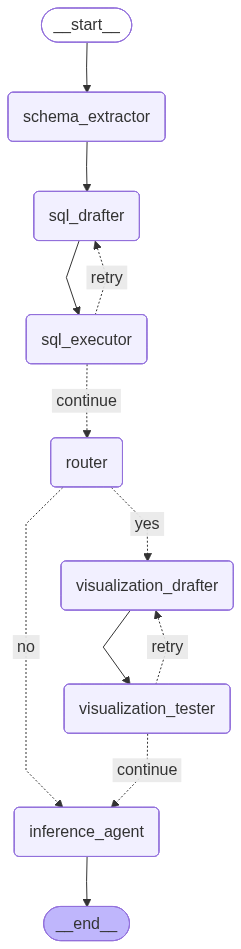

In [23]:
create_workflow()